#### Loading & Simulating the Invisible Gap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('ggplot')
sns.set_palette("viridis")

# 1. Load the foundation
df = pd.read_csv('../data/raw/coffee_production_raw.csv', parse_dates=['arrival_date'])

# 2. Simulate the Pain Point
np.random.seed(42)
df['reported_volume_recall'] = df['volume_mt'] * np.random.uniform(1.2, 1.3, len(df))

print(f"Data audit initiated for {len(df)} transactions.")

Data audit initiated for 589 transactions.


#### Visualizing the Data Integrity Risk

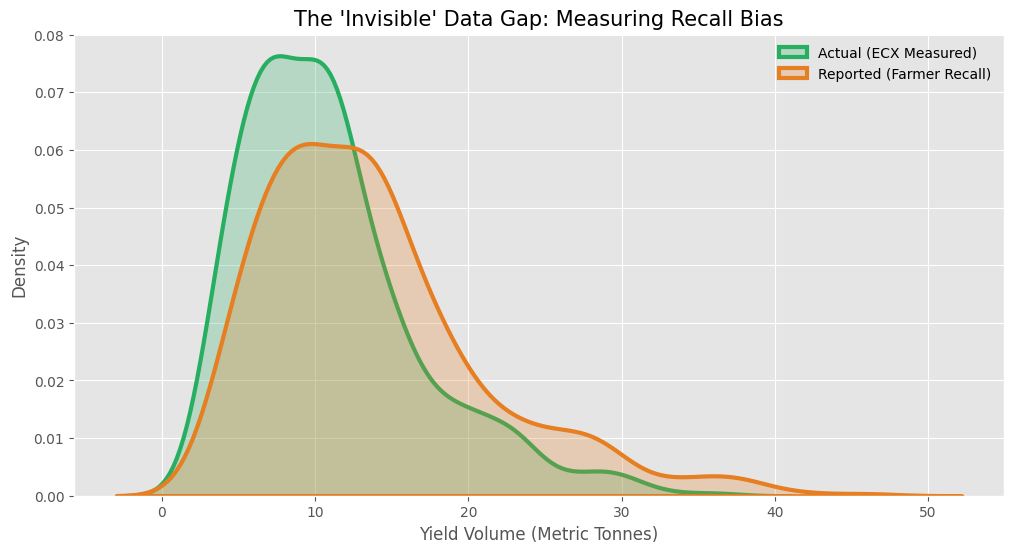

Systematic Recall Bias identified: 25.18%


In [2]:
plt.figure(figsize=(12, 6))

sns.kdeplot(df['volume_mt'], label='Actual (ECX Measured)', fill=True, color='#27ae60', lw=3)
sns.kdeplot(df['reported_volume_recall'], label='Reported (Farmer Recall)', fill=True, color='#e67e22', lw=3)

plt.title("The 'Invisible' Data Gap: Measuring Recall Bias", fontsize=15)
plt.xlabel("Yield Volume (Metric Tonnes)")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.show()

# Quick Metric
bias = (df['reported_volume_recall'].mean() - df['volume_mt'].mean()) / df['volume_mt'].mean()
print(f"Systematic Recall Bias identified: {bias:.2%}")

#### The Statistical Rigor Test

In [3]:
# 1. T-Test for Significance
t_stat, p_val = stats.ttest_rel(df['reported_volume_recall'], df['volume_mt'])

# 2. Cohen's d for Effect Size (Magnitude of the problem)
diff = df['reported_volume_recall'] - df['volume_mt']
cohens_d = np.mean(diff) / np.std(diff, ddof=1)

print("-" * 50)
print("STATISTICAL AUDIT REPORT")
print("-" * 50)
print(f"P-Value:         {p_val:.4e}")
print(f"Cohen's d:       {cohens_d:.2f} (Magnitude of Error)")
print(f"Status:          {'CRITICAL BIAS' if p_val < 0.05 else '🟢 RELIABLE DATA'}")
print("-" * 50)
print("INTERPRETATION: The bias is statistically significant. Decisions based on \n"
      "farmer recall alone will lead to 25% over-allocation of intervention budgets.")

--------------------------------------------------
STATISTICAL AUDIT REPORT
--------------------------------------------------
P-Value:         8.7154e-185
Cohen's d:       1.78 (Magnitude of Error)
Status:          CRITICAL BIAS
--------------------------------------------------
INTERPRETATION: The bias is statistically significant. Decisions based on 
farmer recall alone will lead to 25% over-allocation of intervention budgets.


#### Causal Heatmap (Climate vs. Value)

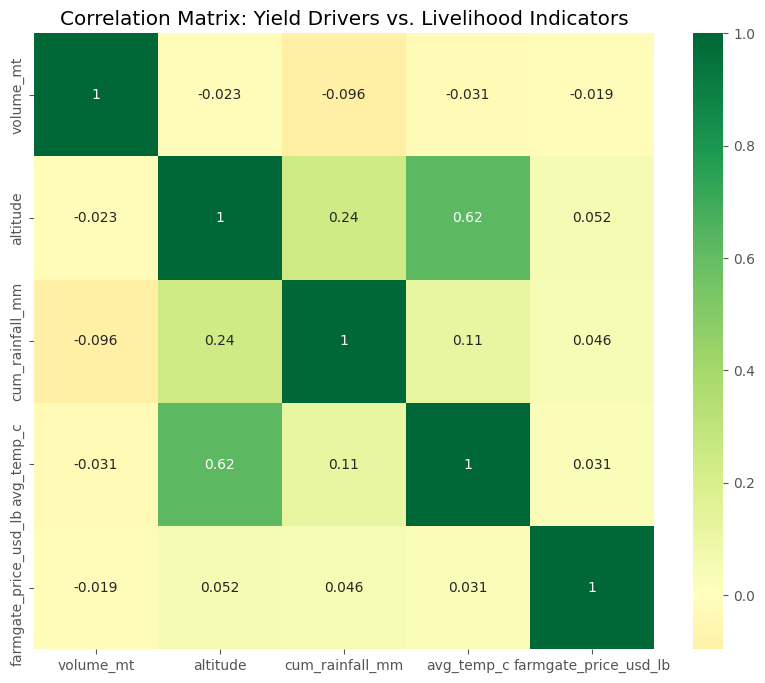

In [4]:
# Select key numerical columns
cols = ['volume_mt', 'altitude', 'cum_rainfall_mm', 'avg_temp_c', 'farmgate_price_usd_lb']
corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title("Correlation Matrix: Yield Drivers vs. Livelihood Indicators")
plt.show()